# 0. Imports and Initial Configs

## 0.1 - Imports

In [1]:
import sys
import warnings
from pathlib import Path

warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Torna o pacote `src` importável independente do diretório de execução do kernel
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

from src.evaluation.known_events import KNOWN_EXTREME_EVENTS
from src.evaluation.metrics import evaluate_anomalies
from src.evaluation.apac_benchmark import compare_with_prophet

## 0.2 - Initial Config

In [2]:
# Comando para remover os warnings (o Prophet/cmdstanpy emite avisos verbosos durante o ajuste)
warnings.filterwarnings("ignore")

# Comando para configurar o pandas e remover o limite de exibição
# de linhas e colunas
pd.set_option('display.max_rows', 100)
pd.set_option('display.max_columns', None)

# Adjust Figure size
plt.rcParams['figure.figsize'] = (12, 8)


# 1. Carregamento de `flagged` (persistido pelo Notebook 02)

O notebook `02_prophet_modeling.ipynb` ajusta o Prophet, gera o forecast e detecta as anomalias, persistindo o resultado (`flagged`) em `dados/processed/flagged_prophet_rmr_2020_2025.csv`. Como o ajuste do Prophet usa amostragem estocástica para o intervalo de incerteza (sem `seed` fixado em `fit_prophet_model`), reproduzir o pipeline aqui de forma independente geraria uma contagem de anomalias diferente a cada execução. Por isso, carregamos diretamente o artefato persistido pelo notebook 02, garantindo que as métricas de validação a seguir sejam calculadas sobre exatamente o mesmo `flagged` reportado lá.

In [3]:
flagged = pd.read_csv(PROJECT_ROOT / "dados" / "processed" / "flagged_prophet_rmr_2020_2025.csv")
flagged['ds'] = pd.to_datetime(flagged['ds'])

n_anomalias = int(flagged['is_anomaly'].sum())
pct_anomalias = n_anomalias / len(flagged) * 100
print(f"Total de anomalias detectadas: {n_anomalias} de {len(flagged)} dias ({pct_anomalias:.2f}%)")

Total de anomalias detectadas: 58 de 2192 dias (2.65%)


Carregamos também `KNOWN_EXTREME_EVENTS` — o catálogo de eventos hidrometeorológicos extremos historicamente documentados na RMR (`src/evaluation/known_events.py`), usado como *ground truth* para a validação a seguir.

In [4]:
print(f"Total de eventos conhecidos catalogados: {len(KNOWN_EXTREME_EVENTS)}")
pd.DataFrame(KNOWN_EXTREME_EVENTS)[["name", "start_date", "end_date"]]


Total de eventos conhecidos catalogados: 8


,name,start_date,end_date
0,Chuvas extremas de 25 de maio de 2022,2022-05-23,2022-05-25
1,Chuvas extremas de 28 de maio de 2022,2022-05-27,2022-05-29
2,Chuvas extremas de 12 de junho de 1965,1965-06-12,1965-06-13
3,Cheia do Rio Beberibe de 11 de agosto de 1970,1970-08-10,1970-08-11
4,Enchente de 19 de julho de 1975,1975-07-18,1975-07-19
5,Chuvas extremas de 24 de maio de 1986,1986-05-24,1986-05-24
6,Chuvas extremas de 1 de agosto de 2000,2000-07-30,2000-08-01
7,Enchente de 30 de maio de 1966,1966-05-30,1966-05-30


# 2. Métricas de Avaliação (Precision, Recall, F1, FPR)

Comparamos as anomalias detectadas pelo Prophet com os eventos conhecidos, considerando uma tolerância de 1 dia ao redor de cada janela de evento (`tolerance_days=1`), via `evaluate_anomalies`.

In [5]:
metrics = evaluate_anomalies(flagged, KNOWN_EXTREME_EVENTS, tolerance_days=1)
pd.DataFrame([metrics])


,precision,recall,f1,false_positive_rate,true_positives,false_positives,false_negatives,true_negatives
0,0.068966,0.444444,0.119403,0.024737,4,54,5,2129


# 3. Benchmark contra os Limiares Operacionais da APAC

Classificamos cada dia segundo os limiares fixos de aviso meteorológico da APAC (`sem_aviso`, `observacao`, `atencao`, `alerta`) e cruzamos essa classificação com a flag de anomalia estatística do Prophet, via `compare_with_prophet`.

In [6]:
result = compare_with_prophet(flagged)
pd.crosstab(result['apac_level'], result['is_anomaly'])


is_anomaly,False,True
apac_level,,
atencao,0,4
observacao,0,3
sem_aviso,2134,51


# 4. Visualização: Eventos Conhecidos vs. Anomalias Detectadas

Sobrepomos à série observada e às anomalias do Prophet as janelas temporais de `KNOWN_EXTREME_EVENTS` (`axvspan`), para inspeção visual de concordância/discordância entre a detecção estatística e o registro histórico.

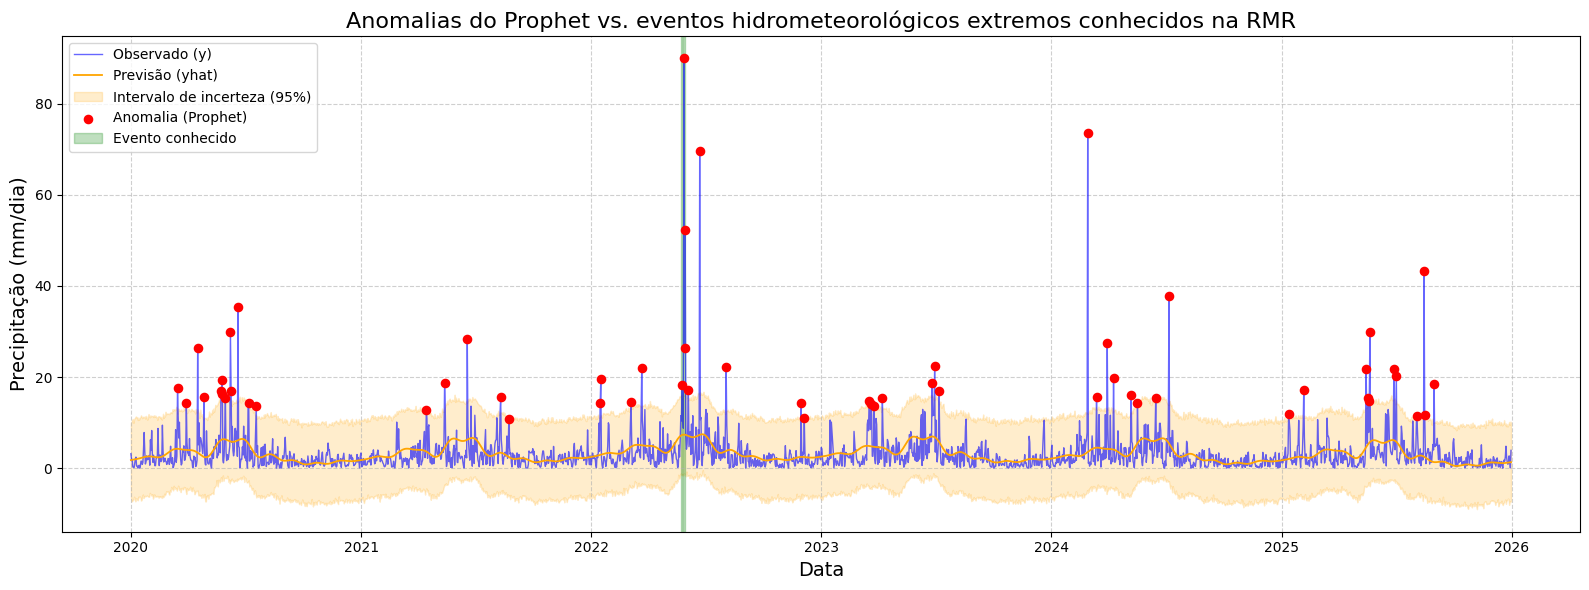

In [7]:
fig, ax = plt.subplots(figsize=(16, 6))

ax.plot(flagged['ds'], flagged['y'], color='b', linewidth=1, alpha=0.6, label='Observado (y)')
ax.plot(flagged['ds'], flagged['yhat'], color='orange', linewidth=1.3, label='Previsão (yhat)')
ax.fill_between(
    flagged['ds'], flagged['yhat_lower'], flagged['yhat_upper'],
    color='orange', alpha=0.2, label='Intervalo de incerteza (95%)',
)

pontos_anomalos = flagged[flagged['is_anomaly']]
ax.scatter(pontos_anomalos['ds'], pontos_anomalos['y'], color='red', s=35, zorder=5, label='Anomalia (Prophet)')

# Restringimos os `axvspan` deste gráfico aos eventos que se sobrepõem à janela
# temporal real da série (2020-2025). Os 6 eventos de 1965-2000 ficam décadas
# fora do eixo x; se desenhados aqui, forçariam o matplotlib a re-escalar o eixo
# para cobri-los, comprimindo toda a série 2020-2025 (onde estão as anomalias e
# os únicos eventos avaliáveis) numa fração ilegível do gráfico. Nenhum evento é
# descartado da análise quantitativa da Seção 2 — a restrição vale só para este plot.
serie_inicio, serie_fim = flagged['ds'].min(), flagged['ds'].max()
eventos_no_periodo = [
    event for event in KNOWN_EXTREME_EVENTS
    if pd.Timestamp(event['end_date']) >= serie_inicio and pd.Timestamp(event['start_date']) <= serie_fim
]

for i, event in enumerate(eventos_no_periodo):
    ax.axvspan(
        pd.Timestamp(event['start_date']), pd.Timestamp(event['end_date']),
        color='green', alpha=0.25,
        label='Evento conhecido' if i == 0 else None,
    )

ax.set_title('Anomalias do Prophet vs. eventos hidrometeorológicos extremos conhecidos na RMR', fontsize=16)
ax.set_xlabel('Data', fontsize=14)
ax.set_ylabel('Precipitação (mm/dia)', fontsize=14)
ax.grid(True, linestyle='--', alpha=0.6)
ax.legend(loc='upper left')
plt.tight_layout()
plt.show()


## Nota: eventos anteriores a 2020 fora da janela da série

Dos 8 eventos catalogados em `KNOWN_EXTREME_EVENTS`, apenas 2 caem dentro do período coberto pela série modelada (2020-2025): as chuvas extremas de 25/05/2022 e de 28/05/2022 — ambos incluídos como `axvspan` no gráfico acima. Os outros 6 eventos catalogados (1965 a 2000) estão fora da janela temporal 2020-2025 da série e, por isso, não possuem dados observados nem previstos (`y`, `yhat`) correspondentes em `flagged` para serem comparados: não podem ser avaliados quantitativamente por `evaluate_anomalies`, que só compara datas presentes em ambos os lados. Por esse mesmo motivo eles foram deliberadamente excluídos dos `axvspan` do gráfico principal acima (ver nota no código da Seção 4) — sua inclusão forçaria o eixo x a se estender por décadas sem dados, comprimindo a série modelada numa fração ilegível do gráfico. A discussão na Seção 5 retoma esse ponto.

## 4.1 - Zoom: eventos de maio/2022

Os dois eventos catalogados que caem dentro do período coberto pela série (23-25/05/2022 e 27-29/05/2022) ficam próximos o suficiente para serem inspecionados numa única janela ampliada, seguindo o mesmo padrão de visualização do notebook 02 (seção `4.2 - Zoom: evento extremo de maio/2022`), permitindo verificar visualmente a concordância/discordância entre os eventos conhecidos (faixas verdes) e as anomalias detectadas pelo Prophet (pontos vermelhos).

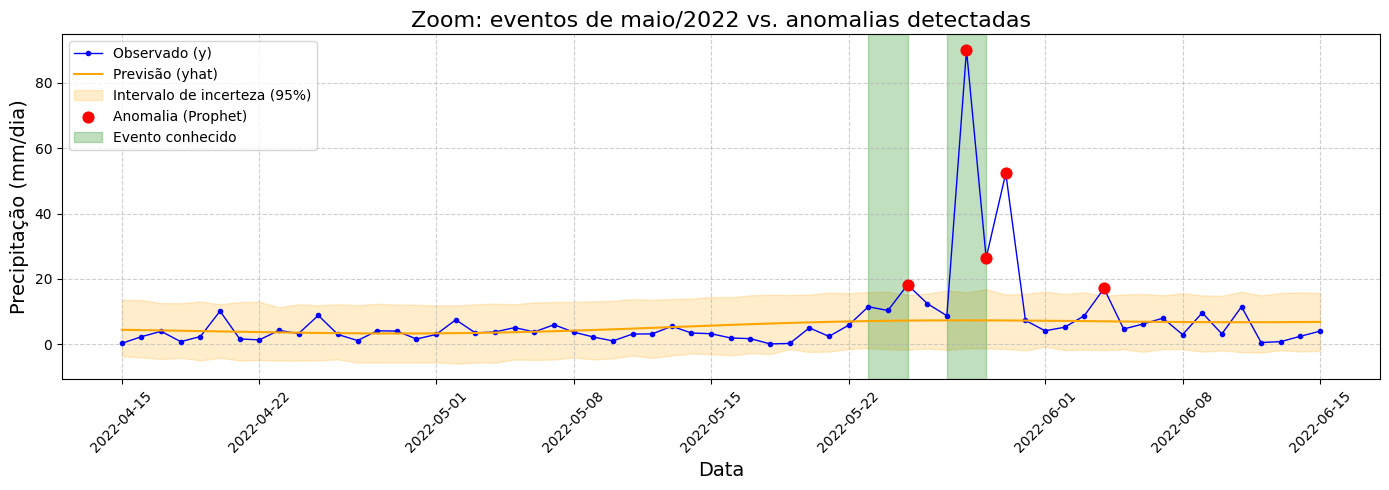

In [8]:
zoom = flagged[(flagged['ds'] >= '2022-04-15') & (flagged['ds'] <= '2022-06-15')]

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(zoom['ds'], zoom['y'], color='b', marker='o', markersize=3, linewidth=1, label='Observado (y)')
ax.plot(zoom['ds'], zoom['yhat'], color='orange', linewidth=1.5, label='Previsão (yhat)')
ax.fill_between(
    zoom['ds'], zoom['yhat_lower'], zoom['yhat_upper'],
    color='orange', alpha=0.2, label='Intervalo de incerteza (95%)',
)

zoom_anomalias = zoom[zoom['is_anomaly']]
ax.scatter(zoom_anomalias['ds'], zoom_anomalias['y'], color='red', s=60, zorder=5, label='Anomalia (Prophet)')

for i, event in enumerate(eventos_no_periodo):
    ax.axvspan(
        pd.Timestamp(event['start_date']), pd.Timestamp(event['end_date']),
        color='green', alpha=0.25,
        label='Evento conhecido' if i == 0 else None,
    )

ax.set_title('Zoom: eventos de maio/2022 vs. anomalias detectadas', fontsize=16)
ax.set_xlabel('Data', fontsize=14)
ax.set_ylabel('Precipitação (mm/dia)', fontsize=14)
ax.grid(True, linestyle='--', alpha=0.6)
ax.legend(loc='upper left')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


## 4.2 - Verificação: dias sinalizados por evento (tolerância de 1 dia)

Para que a afirmação específica sobre quais dias foram sinalizados em cada janela de evento (discutida na Seção 5) seja verificável diretamente a partir da saída do notebook — e não apenas afirmada em texto —, listamos abaixo, para cada um dos dois eventos de maio/2022, os dias de `flagged` dentro da janela do evento com a mesma tolerância de 1 dia usada em `evaluate_anomalies` (`tolerance_days=1`).

In [9]:
tolerancia = pd.Timedelta(days=1)

evento_2505 = KNOWN_EXTREME_EVENTS[0]  # Chuvas extremas de 25 de maio de 2022
ini_2505 = pd.Timestamp(evento_2505['start_date']) - tolerancia
fim_2505 = pd.Timestamp(evento_2505['end_date']) + tolerancia
print(f"Janela do evento de 25/05/2022 (tolerância de {tolerancia.days} dia): {ini_2505.date()} a {fim_2505.date()}")

flagged[flagged['ds'].between(ini_2505, fim_2505)][['ds', 'y', 'is_anomaly', 'severity']]


Janela do evento de 25/05/2022 (tolerância de 1 dia): 2022-05-22 a 2022-05-26


,ds,y,is_anomaly,severity
872,2022-05-22,5.879115,False,0.000000
873,2022-05-23,11.511595,False,0.000000
874,2022-05-24,10.367428,False,0.000000
875,2022-05-25,18.237219,True,3.116404
876,2022-05-26,12.493035,False,0.000000


In [10]:
evento_2805 = KNOWN_EXTREME_EVENTS[1]  # Chuvas extremas de 28 de maio de 2022
ini_2805 = pd.Timestamp(evento_2805['start_date']) - tolerancia
fim_2805 = pd.Timestamp(evento_2805['end_date']) + tolerancia
print(f"Janela do evento de 28/05/2022 (tolerância de {tolerancia.days} dia): {ini_2805.date()} a {fim_2805.date()}")

flagged[flagged['ds'].between(ini_2805, fim_2805)][['ds', 'y', 'is_anomaly', 'severity']]


Janela do evento de 28/05/2022 (tolerância de 1 dia): 2022-05-26 a 2022-05-30


,ds,y,is_anomaly,severity
876,2022-05-26,12.493035,False,0.000000
877,2022-05-27,8.761647,False,0.000000
878,2022-05-28,89.964200,True,74.073126
879,2022-05-29,26.446712,True,9.577035
880,2022-05-30,52.305065,True,37.084333


# 5. Discussão

**Recall e eventos capturados.** Dos 8 eventos catalogados em `KNOWN_EXTREME_EVENTS`, apenas 2 caem dentro do período coberto pela série modelada (2020-2025): as chuvas extremas de 25/05/2022 e de 28/05/2022. Os outros 6 eventos (1965 a 2000) são anteriores ao início da série e, portanto, não têm dias correspondentes em `flagged` — não podem ser avaliados quantitativamente por `evaluate_anomalies`, que só compara datas presentes em ambos os lados. Com tolerância de 1 dia, a união das janelas dos dois eventos de 2022 totaliza 9 dias-evento, dos quais o Prophet capturou 4 como anomalia (**recall = 0,444**): o pico da janela de 25/05 (apenas o dia 25/05 em si, não 23 ou 24/05) e três dos cinco dias da janela de 28/05 (28, 29 e 30/05 — incluindo o dia de maior precipitação de toda a série, 89,96 mm em 28/05/2022). O evento de 25/05 foi, portanto, apenas parcialmente sinalizado, enquanto o de 28/05 (mais severo) foi bem capturado.

**Precisão baixa e falsos positivos.** Das 58 anomalias detectadas (2,65% dos 2.192 dias), só 4 coincidem com um dia-evento documentado, resultando em **precision = 0,069** (54 falsos positivos) e **F1 = 0,119**. A taxa de falsos positivos sobre o total de dias não-evento, no entanto, é baixa (**FPR = 0,025**), já que a maioria esmagadora dos 2.183 dias sem evento catalogado é corretamente classificada como normal (2.129 verdadeiros negativos). A precisão baixa não deve ser lida como "o modelo erra muito": o catálogo de eventos consultado na literatura documenta apenas 2 episódios extremos dentro da janela 2020-2025, um recorte necessariamente incompleto (a pesquisa bibliográfica não esgota todo evento de chuva forte ocorrido nesses 6 anos). Muitas das 54 anomalias "sem correspondência" (falsos positivos) são provavelmente eventos de chuva real e localmente atípicos que simplesmente não foram documentados na literatura consultada, e não necessariamente erros do modelo.

**Divergência entre o limiar fixo da APAC e a detecção estatística do Prophet.** O cruzamento `apac_level` x `is_anomaly` (Seção 3) evidencia o ponto central desta discussão: nenhum dia da série chegou ao nível "alerta" da APAC (>= 100 mm; o máximo histórico da série, 89,96 mm, fica abaixo desse limiar), e todos os 7 dias classificados como "atencao" (4 dias) ou "observacao" (3 dias) pela APAC também foram sinalizados como anômalos pelo Prophet — ou seja, nos extremos superiores de chuva absoluta, os dois critérios concordam integralmente. A divergência aparece no outro sentido: **51 das 58 anomalias do Prophet (87,9%)** correspondem a dias classificados como "sem_aviso" pela APAC (chuva <= 30 mm, portanto sem nenhum aviso operacional). Isso ocorre porque a APAC usa limiares fixos, válidos para qualquer época do ano, enquanto o intervalo de confiança do Prophet (`yhat_upper`) acompanha a sazonalidade climatológica aprendida: em períodos secos (ex.: janeiro, dezembro), o valor esperado de chuva é de poucos milímetros, de modo que um dia com 15-25 mm — trivial para a APAC — está muito acima do padrão local esperado e é sinalizado como anômalo pelo Prophet. Ou seja, um dia pode ser estatisticamente anômalo para a climatologia da RMR sem nunca disparar um aviso operacional da APAC, e, inversamente (não observado nesta série, mas fisicamente possível), um dia poderia ultrapassar o limiar de "atencao" da APAC em pleno pico da estação chuvosa sem se destacar da climatologia esperada pelo Prophet.

**Nota sobre reprodutibilidade.** O ajuste do Prophet via otimização MAP (`cmdstanpy`) não é perfeitamente determinístico entre execuções (não há `seed` fixado em `fit_prophet_model`), o que antes fazia este notebook reajustar o modelo de forma independente e reportar contagens de anomalias divergentes das do notebook 02. Isso foi corrigido: o notebook 02 agora persiste `flagged` em `dados/processed/flagged_prophet_rmr_2020_2025.csv`, e este notebook carrega esse arquivo diretamente (Seção 1) em vez de reajustar o Prophet. Todos os números acima — 58 anomalias, precision, recall, F1, FPR e o cruzamento com a APAC — são calculados sobre exatamente o mesmo `flagged` reportado no notebook 02, e são estáveis entre reexecuções deste notebook (mudam apenas se o notebook 02 for reexecutado e persistir um novo `flagged`).